# PedalPulse: a CRISP-DM bike-sharing demand project

This executed notebook is a concise, reproducible narrative over the modular package and frozen evaluation artifacts. It performs data-quality and leakage checks, displays saved analysis results, and deliberately **does not recompute locked-test metrics**. The selected model was already evaluated once.

## 1. Business understanding

The imaginary operator needs one-hour-ahead, system-wide demand estimates for rebalancing, staffing, and capacity planning. Success was defined before model selection as at least 10% RMSLE and 5% MAE improvement over a rolling seasonal-naive baseline. Predictions are decision support, not automatic service-allocation rules.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "pedalpulse").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from within assignment-1-pedalpulse")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
TABLES = PROJECT_ROOT / "artifacts" / "tables"
FIGURES = PROJECT_ROOT / "artifacts" / "figures"
DATA_PATH = Path(os.environ.get("PEDALPULSE_DATA_PATH", PROJECT_ROOT / "data" / "raw" / "train.csv"))

from pedalpulse.data import chronological_split, safe_predictor_frame

pd.set_option("display.max_columns", 20)
print("Reproducible project imports: PASS")

Reproducible project imports: PASS


## 2. Data understanding

The raw Kaggle training file is loaded without mutation. The following cell reports its structure and validates the target identity that creates the central leakage risk.

In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError("Download Kaggle train.csv and configure PEDALPULSE_DATA_PATH or place it in data/raw/train.csv")

raw = pd.read_csv(DATA_PATH)
timestamps = pd.to_datetime(raw["datetime"])
summary = pd.DataFrame({
    "measure": ["rows", "columns", "duplicate rows", "missing cells", "timestamp start", "timestamp end"],
    "value": [len(raw), raw.shape[1], raw.duplicated().sum(), raw.isna().sum().sum(), timestamps.min(), timestamps.max()],
})
display(summary)
print("count equals casual + registered for every row:", bool((raw["count"] == raw["casual"] + raw["registered"]).all()))
display(raw.dtypes.rename("dtype").to_frame())

count equals casual + registered for every row: True


,measure,value
0,rows,10886
1,columns,12
2,duplicate rows,0
3,missing cells,0
4,timestamp start,2011-01-01 00:00:00
5,timestamp end,2012-12-19 23:00:00


,dtype
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


## 3. Data preparation and leakage control

Calendar and cyclical features are generated inside a scikit-learn pipeline. `safe_predictor_frame` explicitly selects the permitted predictor contract, so `casual`, `registered`, and `count` cannot enter preprocessing.

In [3]:
splits = chronological_split(raw)
split_summary = pd.DataFrame([
    {
        "split": name,
        "rows": len(frame),
        "start": pd.to_datetime(frame["datetime"]).min(),
        "end": pd.to_datetime(frame["datetime"]).max(),
    }
    for name, frame in splits.items()
])
display(split_summary)
safe_columns = safe_predictor_frame(splits["train"]).columns.tolist()
print("Permitted raw predictors:", safe_columns)
print("Leakage fields in permitted predictors:", sorted({"casual", "registered", "count"}.intersection(safe_columns)))

Permitted raw predictors: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']
Leakage fields in permitted predictors: []


,split,rows,start,end
0,train,8151,2011-01-01,2012-06-19 23:00:00
1,validation,1368,2012-07-01,2012-09-19 23:00:00
2,test,1367,2012-10-01,2012-12-19 23:00:00


## 4. Exploratory data analysis

The executed EDA found strong hour and calendar structure. Working-day commuting peaks are observed evidence; explanations about why riders behave this way remain hypotheses rather than causal findings.

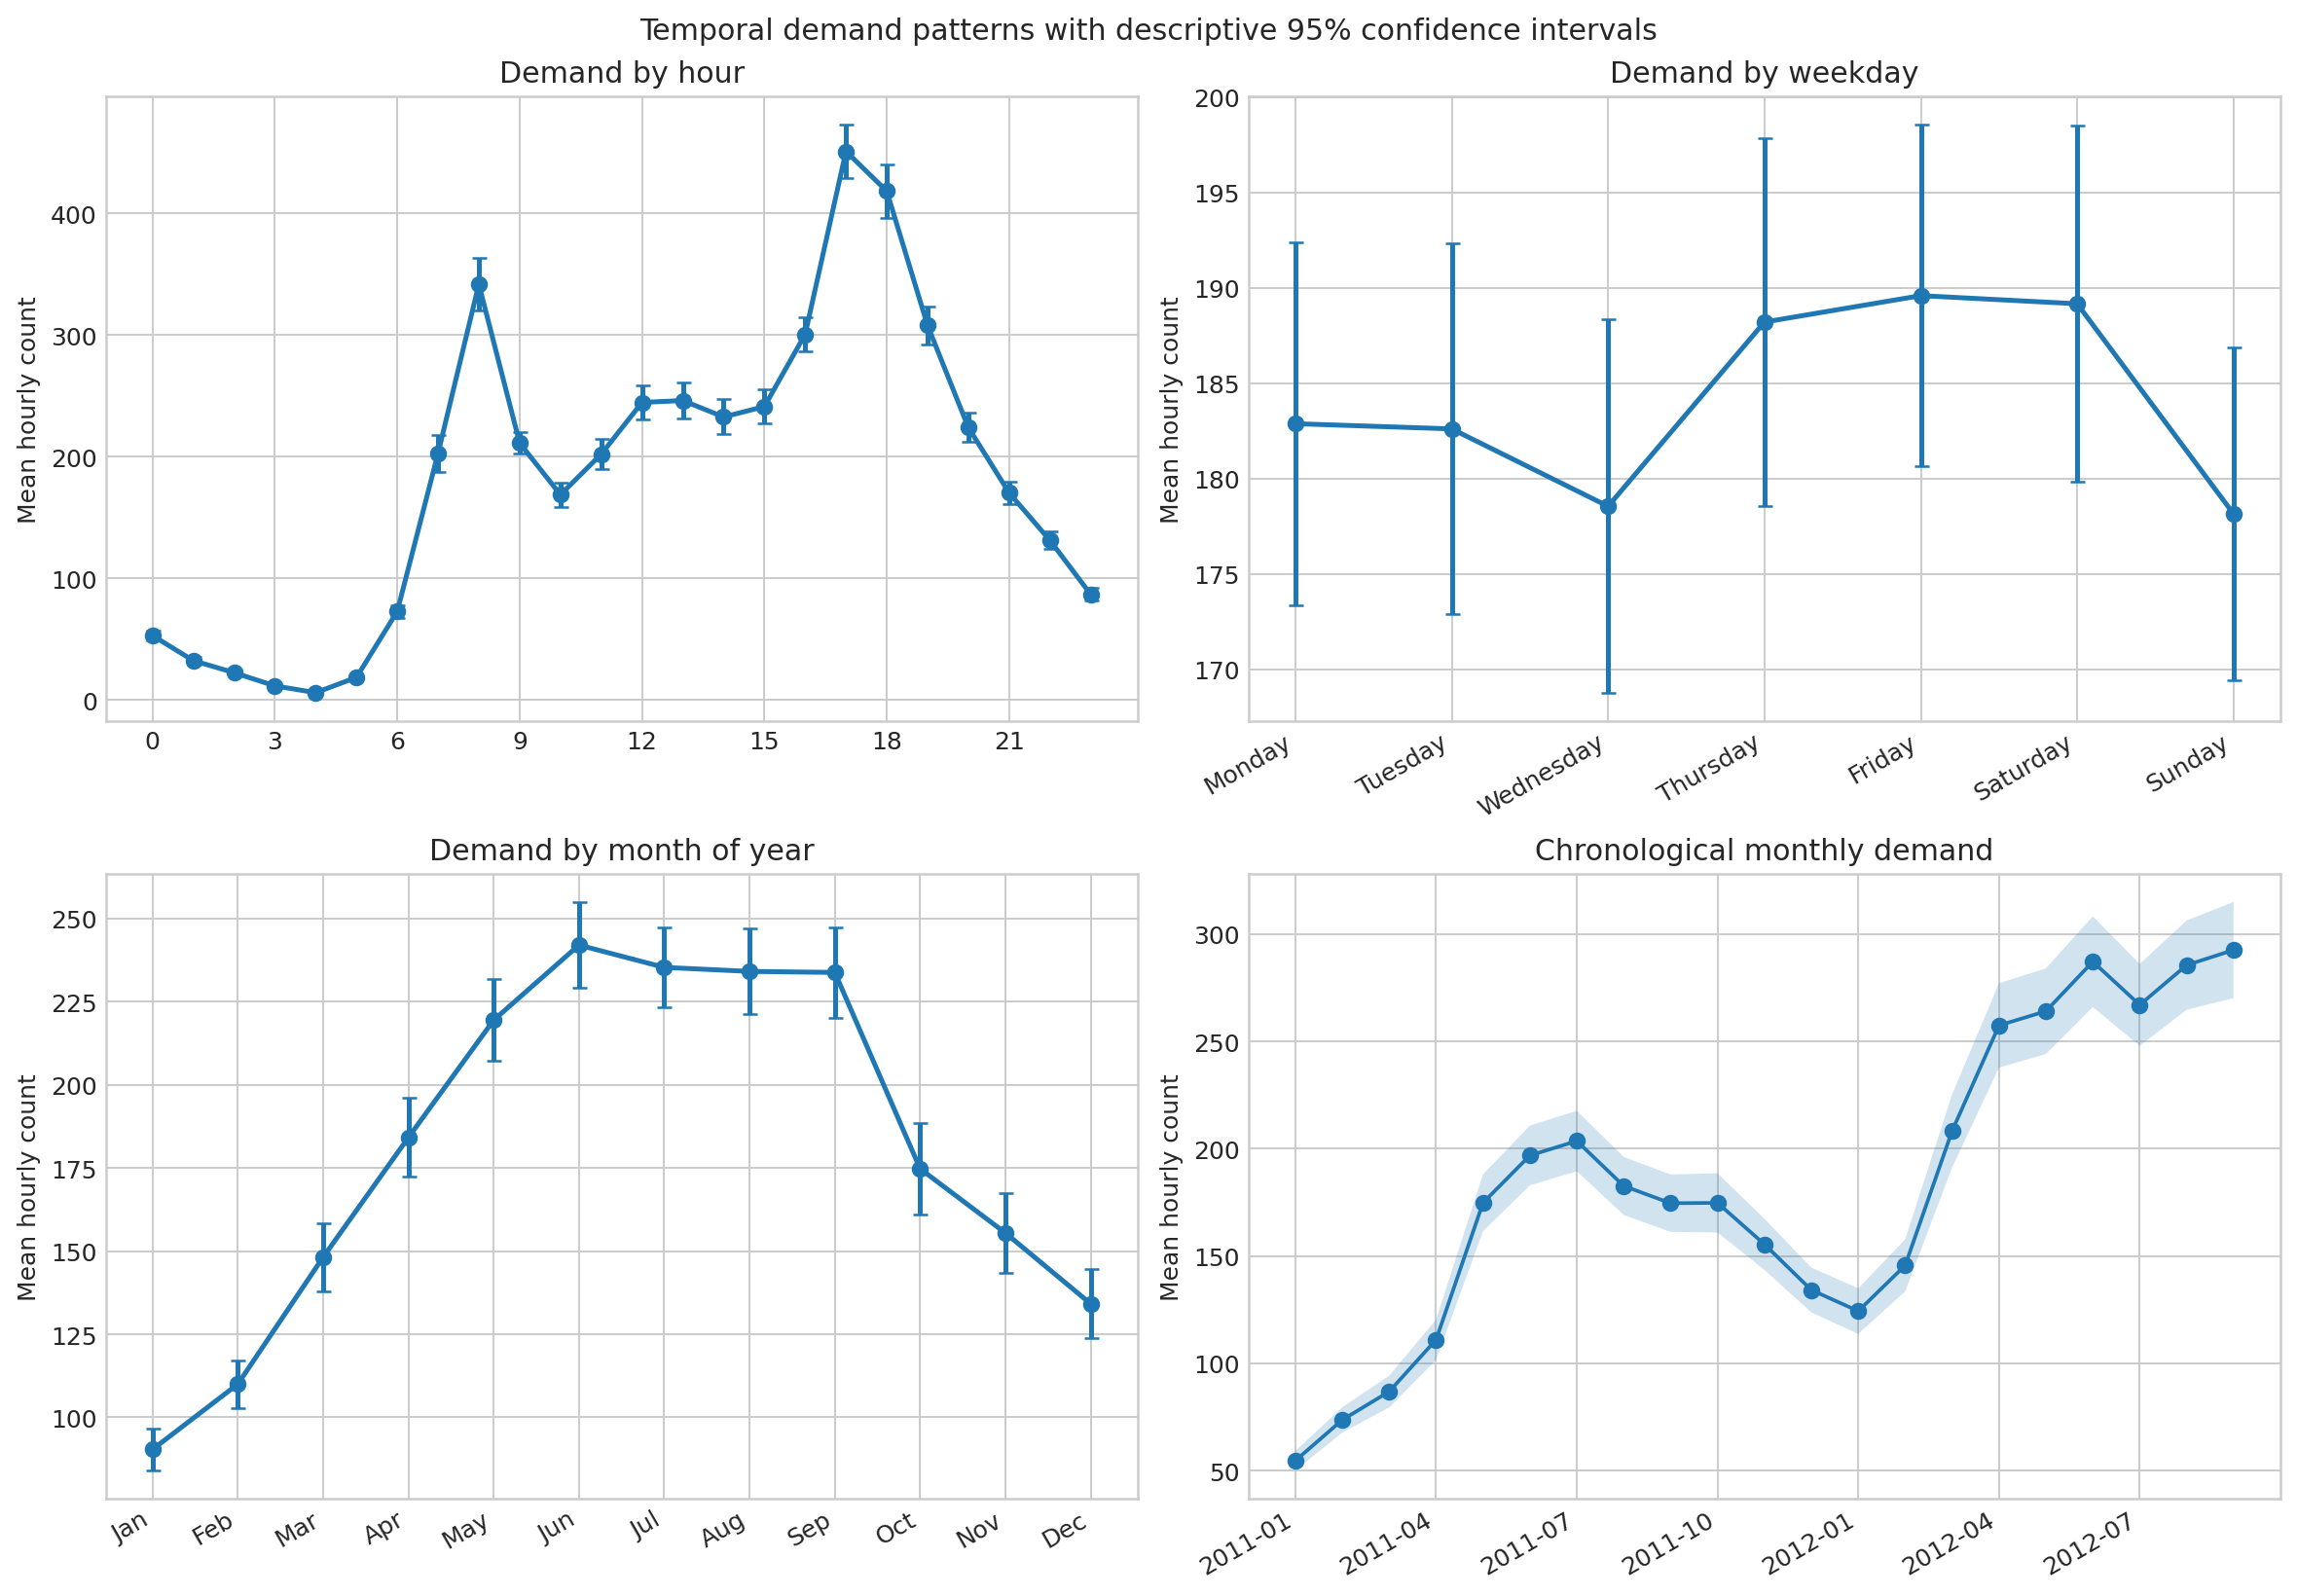

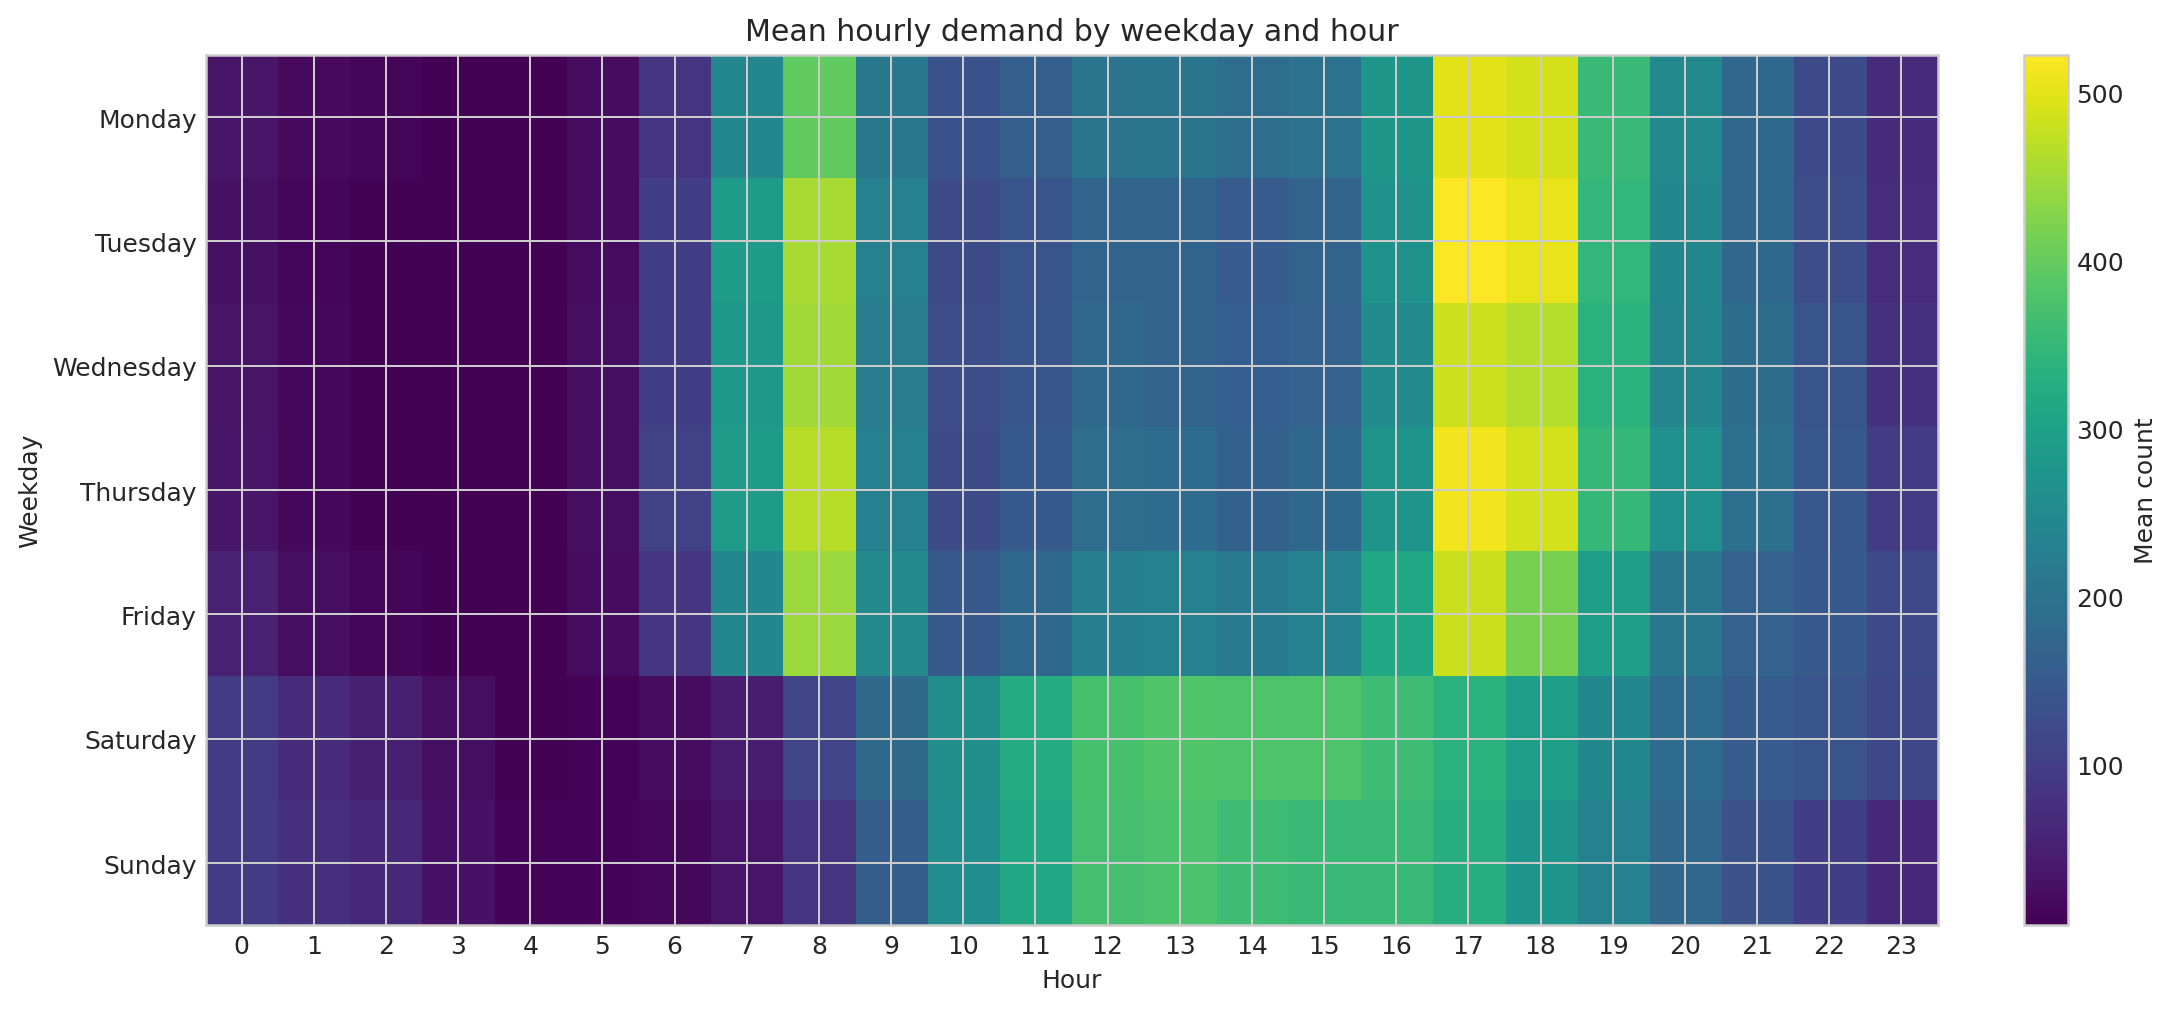

In [4]:
display(Image(filename=str(FIGURES / "temporal_demand_patterns.png"), width=1000))
display(Image(filename=str(FIGURES / "hour_weekday_heatmap.png"), width=900))

**Interpretation.** Demand varies strongly by hour and weekday. The heatmap shows weekday morning/evening peaks and a different weekend profile. These patterns justify temporal features and a chronological validation design.

## 5. Outliers, clustering, and feature selection

The training-only IQR diagnostic flagged 258 high-demand periods, but many coincide with legitimate evening commuting demand. K-Means k=2 was selected under a minimum 5% cluster-size rule and did not use the demand target.

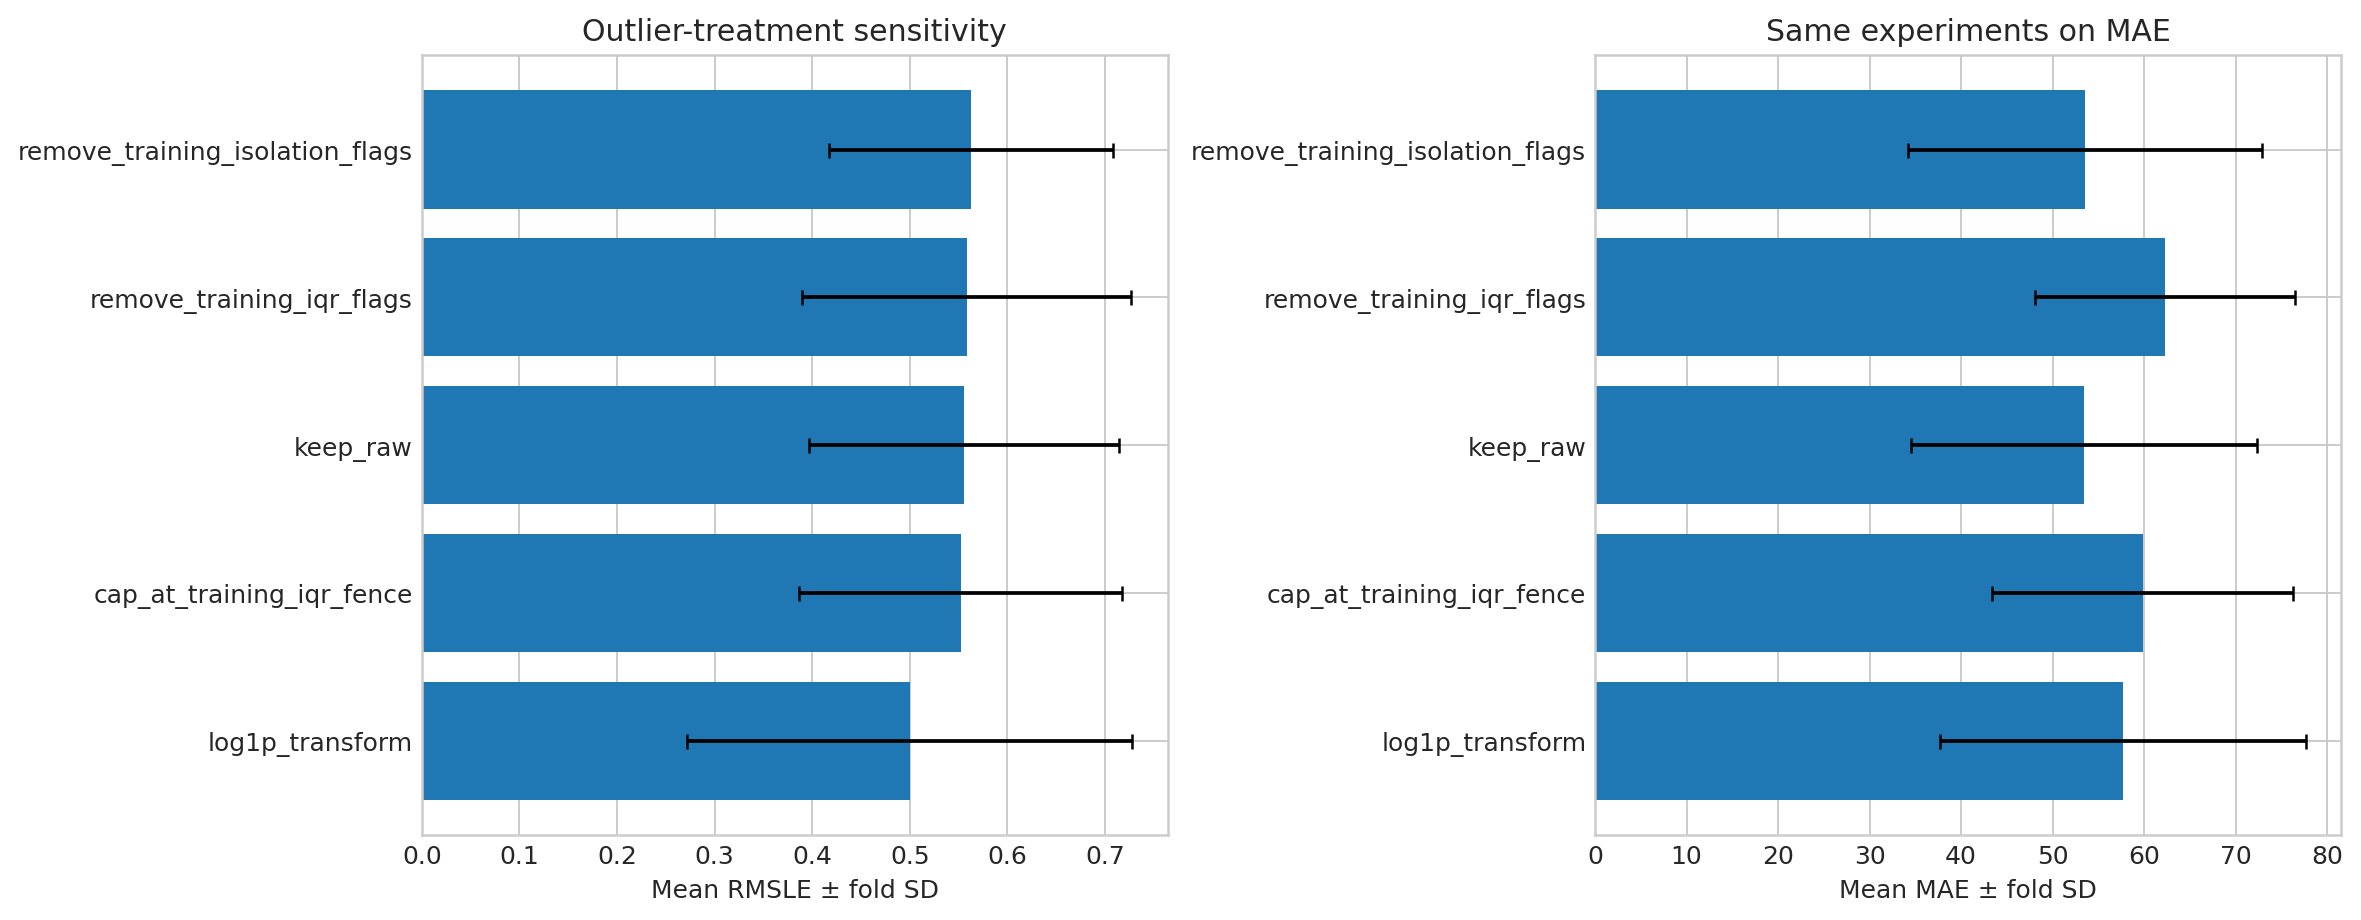

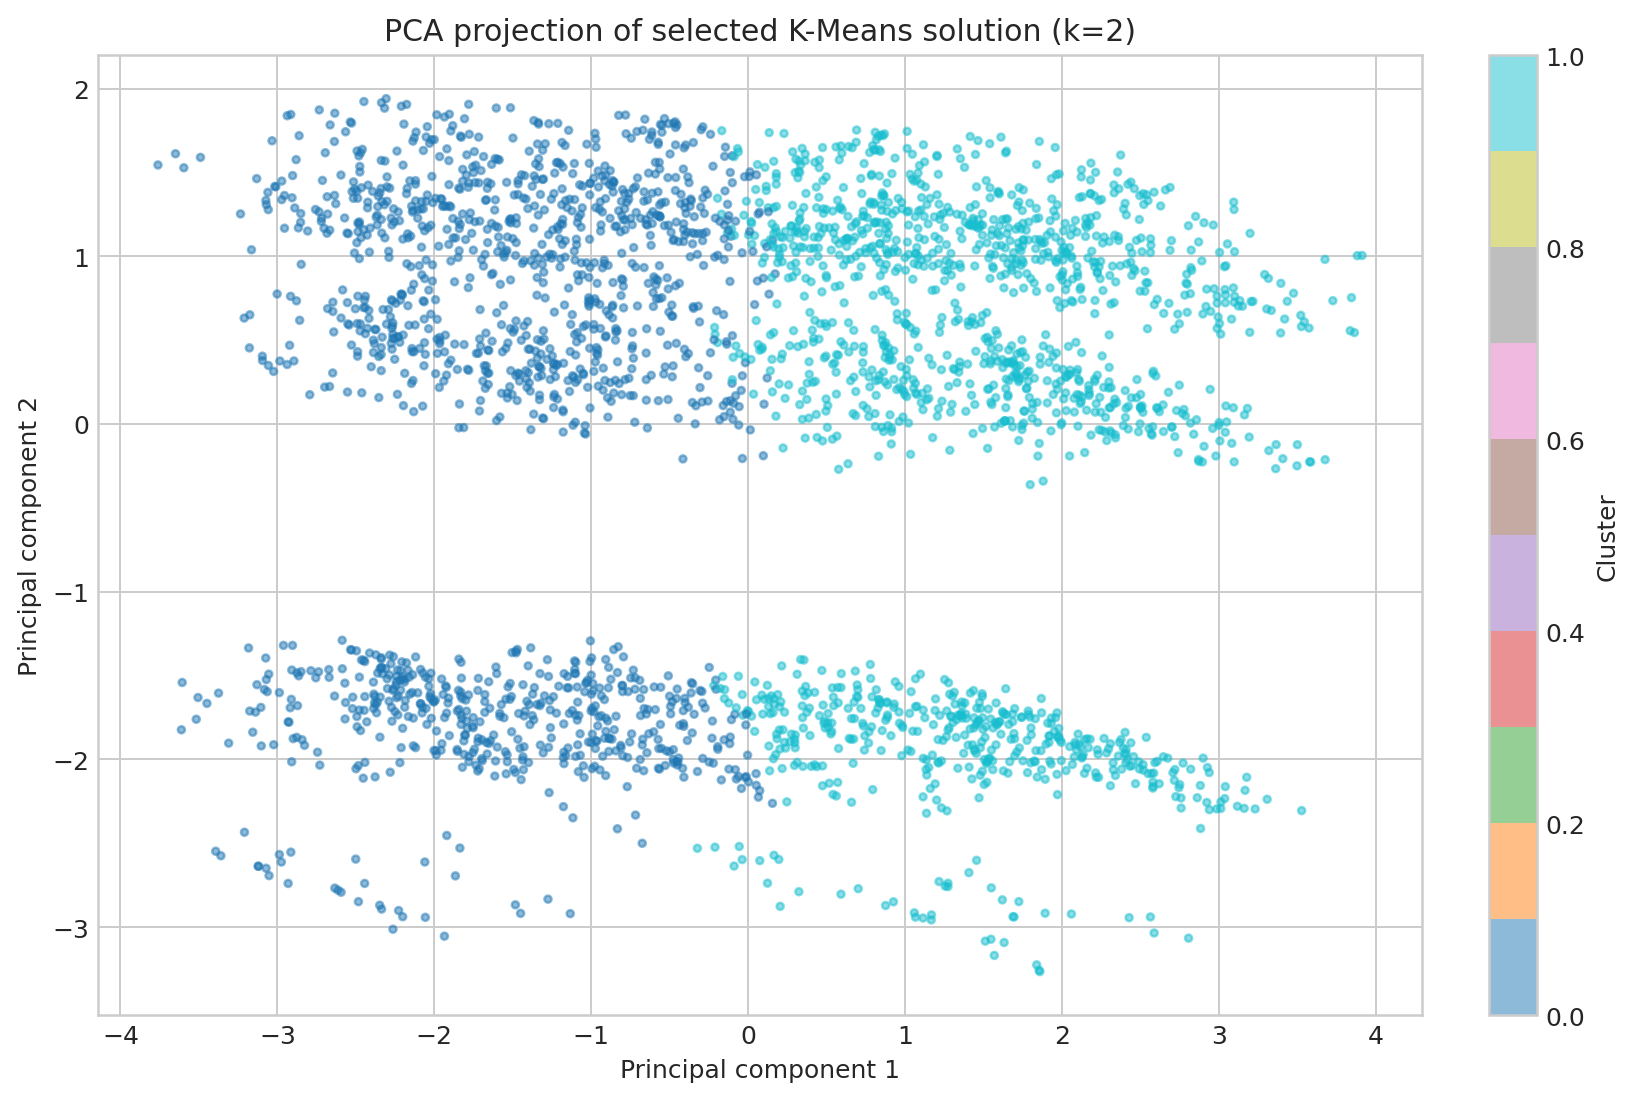

,cluster,persona,rows,share_pct,dominant_hour,dominant_weekday_monday_0,workingday_share_pct,weekend_share_pct,mean_temp,mean_humidity,mean_windspeed,posthoc_mean_count_not_used_for_fit,posthoc_median_count_not_used_for_fit
0,0,Morning workday conditions (cluster 0),4033,49.478592,6,5,65.286387,31.961319,12.857511,60.248202,13.678993,113.380362,78.0
1,1,Mixed daytime conditions (cluster 1),4118,50.521408,15,1,71.199611,26.274891,25.611161,62.144488,12.768833,221.068237,184.0


,selection,features,fit_seconds,mae,rmse,rmsle,r2
0,domain_selected,27,0.379106,42.008164,64.428241,0.399710,0.918780
1,without_weather_inputs,63,0.504214,55.146100,85.965490,0.400267,0.855403
2,mutual_information_top30,30,1.366695,48.893759,73.441172,0.404756,0.894466
3,all_features,74,0.587775,43.633883,66.906711,0.417517,0.912411
4,permutation_top30,30,0.419869,84.243065,115.637991,0.460156,0.738354
5,without_temporal_inputs,15,0.369761,151.375907,207.143380,1.211816,0.160435


In [5]:
display(Image(filename=str(FIGURES / "outlier_sensitivity.png"), width=850))
display(Image(filename=str(FIGURES / "cluster_pca_projection.png"), width=850))
display(pd.read_csv(TABLES / "cluster_operational_personas.csv"))
display(pd.read_csv(TABLES / "feature_selection_ablation.csv").sort_values("rmsle").head(6))

**Interpretation.** Log transformation had the best RMSLE in the fixed-model outlier sensitivity study, while deletion was not justified. The PCA display is a projection, not proof of complete separation. Domain-selected features led the fixed-HGB ablation, and removing temporal features caused the largest deterioration.

## 6. Temporal modeling

Five expanding temporal folds compared dummy, seasonal-naive, linear, Random Forest, and gradient-boosting candidates. XGBoost was skipped because it was unavailable; no result is invented for it.

,family,candidate,mae_mean,mae_std,rmsle_mean,rmsle_std,r2_mean
0,Random Forest,rf_raw_depth18_leaf1,55.200443,18.512773,0.460429,0.157291,0.738471
1,HistGradientBoosting,hgb_log_leaf15_lr005,60.115432,17.713331,0.498271,0.212855,0.689947
2,Seasonal naive,seasonal_naive,58.855281,9.902561,0.597727,0.045875,0.676278
3,Elastic Net,elastic_log_a005_l10.5,84.554153,16.357066,0.670132,0.164547,0.470350
4,Ridge,ridge_log_a1,87.034642,20.520059,0.671147,0.153790,0.452668
5,Dummy median,dummy_median,153.920781,49.139129,1.390029,0.063429,-0.349207
6,Dummy mean,dummy_mean,146.223202,43.309773,1.405850,0.096600,-0.161010


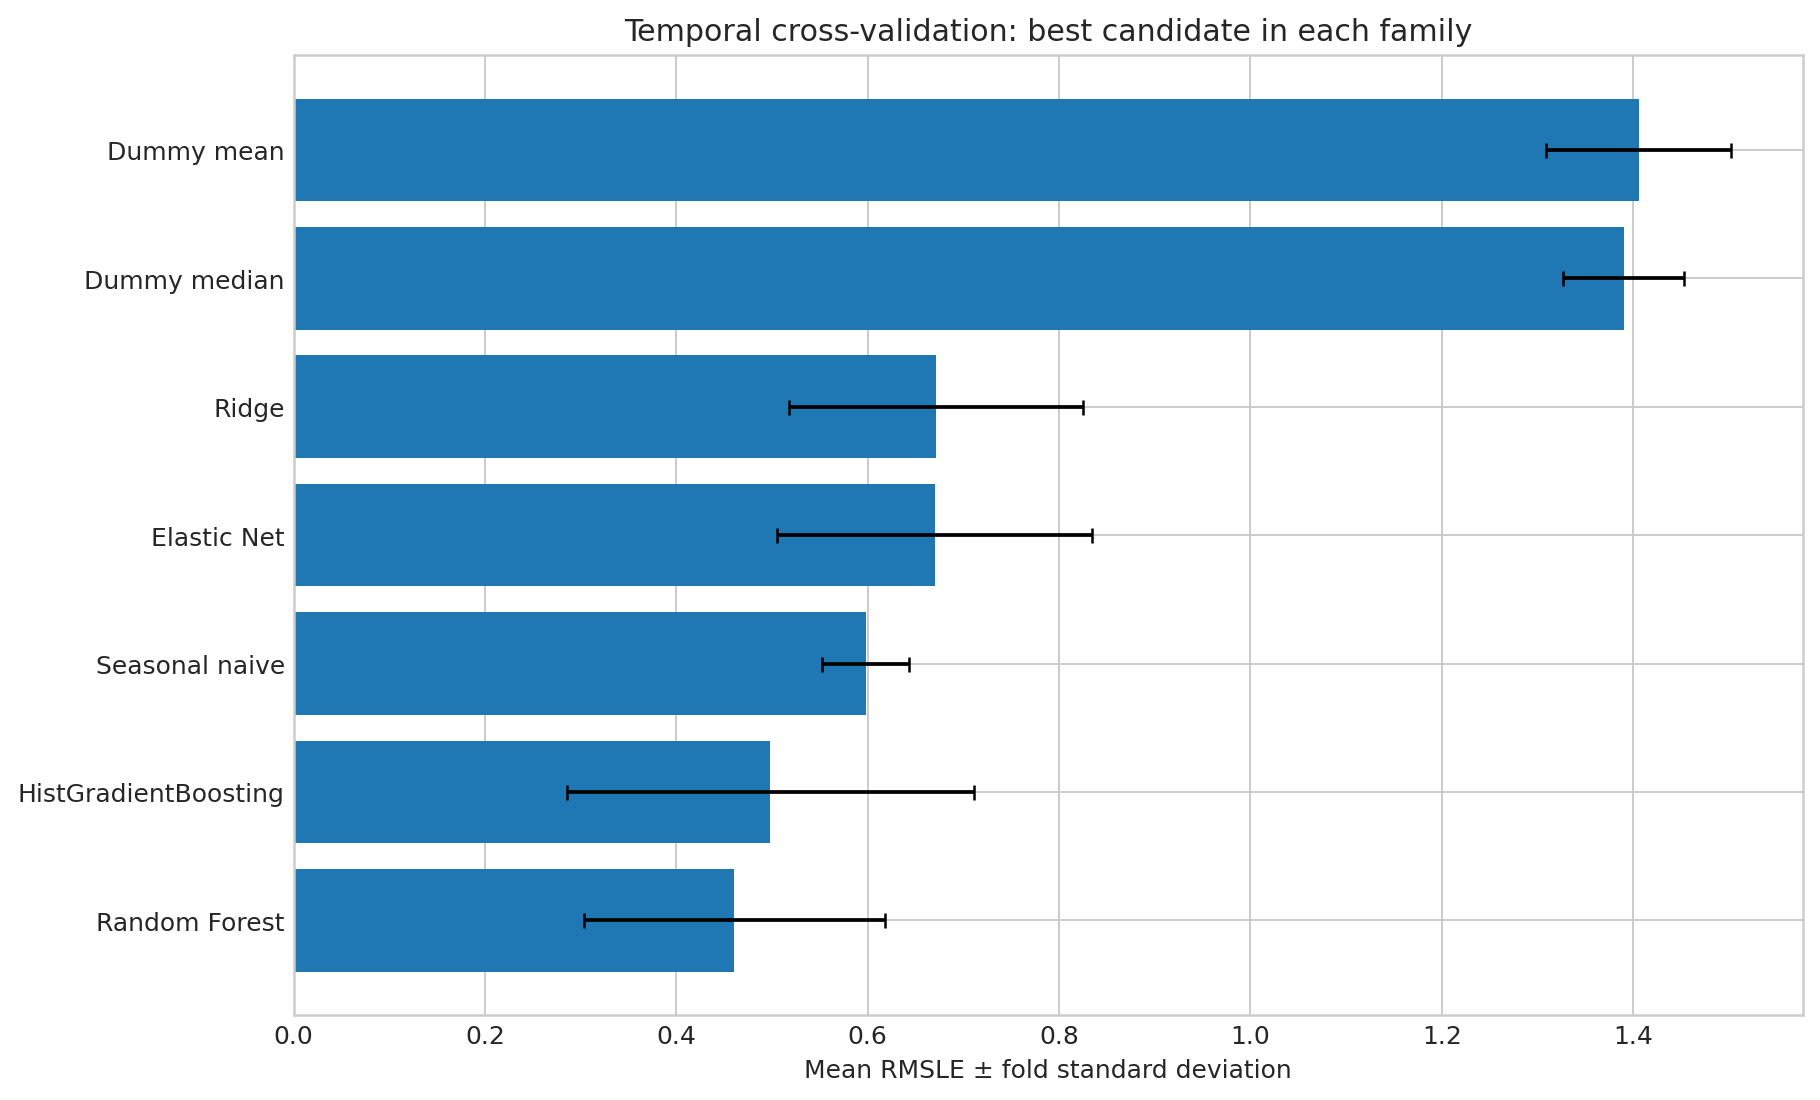

In [6]:
family_results = pd.read_csv(TABLES / "model_family_winners.csv")
display(family_results[["family", "candidate", "mae_mean", "mae_std", "rmsle_mean", "rmsle_std", "r2_mean"]])
display(Image(filename=str(FIGURES / "model_family_comparison.png"), width=900))

**Interpretation.** Random Forest had the lowest mean development RMSLE, but its fold variation is substantial. The model was selected on development evidence rather than complexity or locked-test performance.

## 7. Locked evaluation and explainability

This section reads the immutable metrics produced by the single locked-test evaluation. It does not call a scoring function or refit a model.

,candidate,evaluation,mae,rmse,rmsle,r2
0,rf_raw_depth18_leaf1,locked_test,57.409156,83.410147,0.373901,0.832713
1,seasonal_naive,locked_test,62.737381,106.175973,0.525518,0.728932


,check,measured,status
0,casual absent from model inputs,True,PASS
1,registered absent from model inputs,True,PASS
2,count absent from model inputs,True,PASS
3,development ends before test begins,True,PASS
4,selected-model locked-test metric evaluations,1,PASS
5,raw input hash unchanged,True,PASS


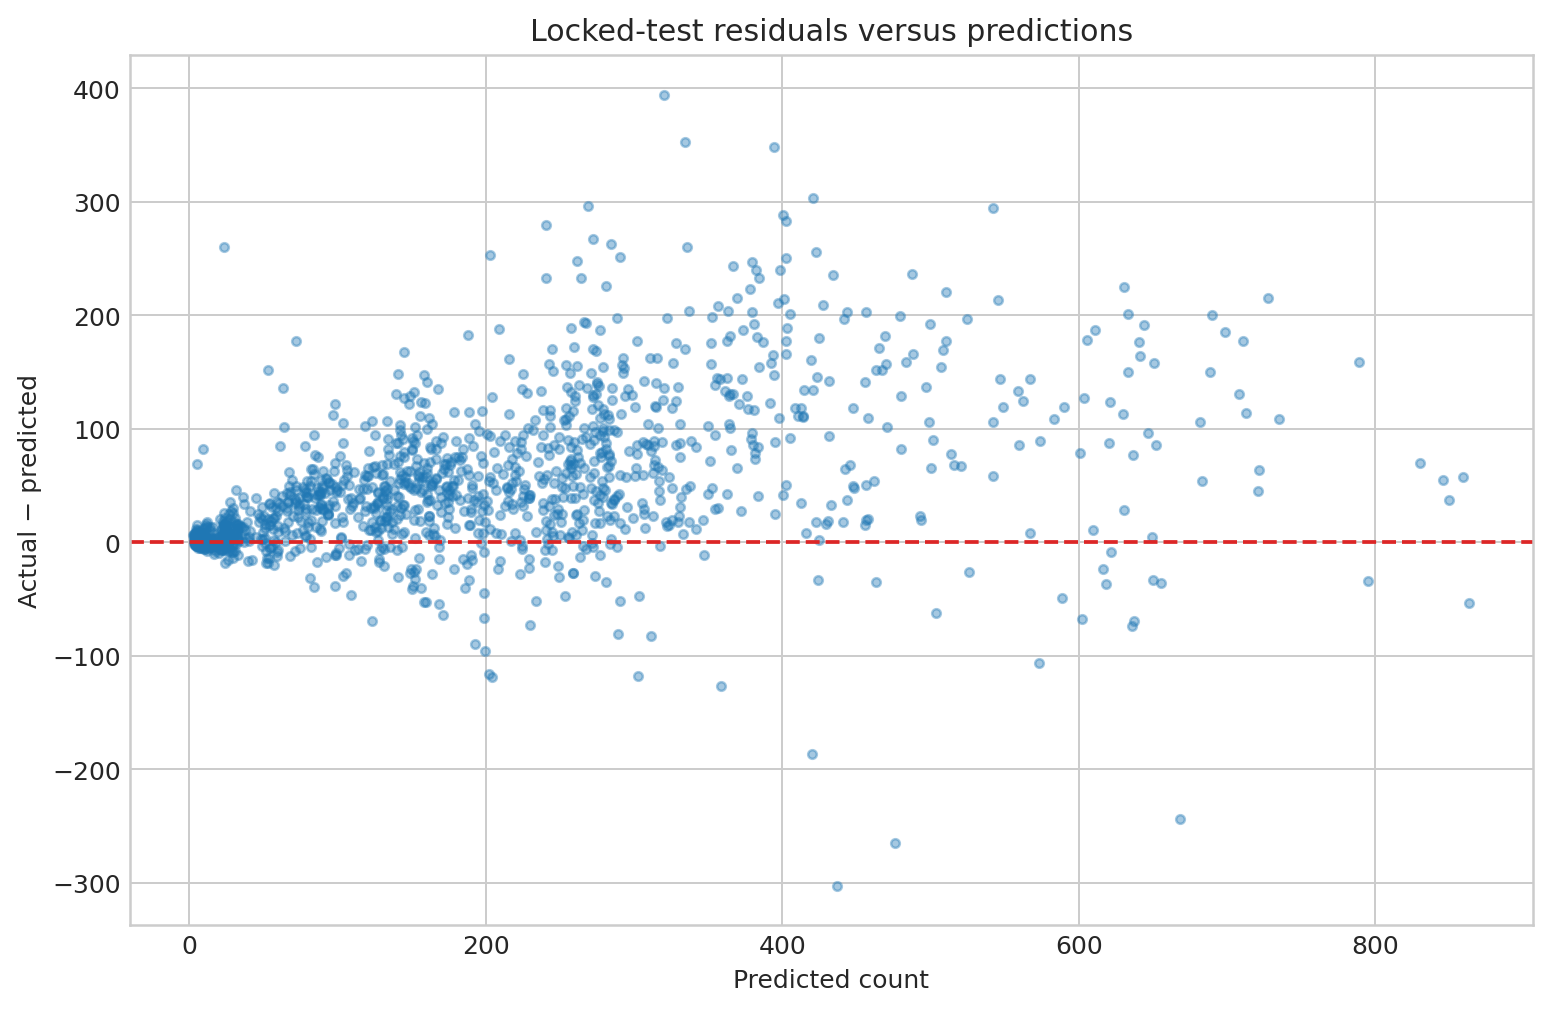

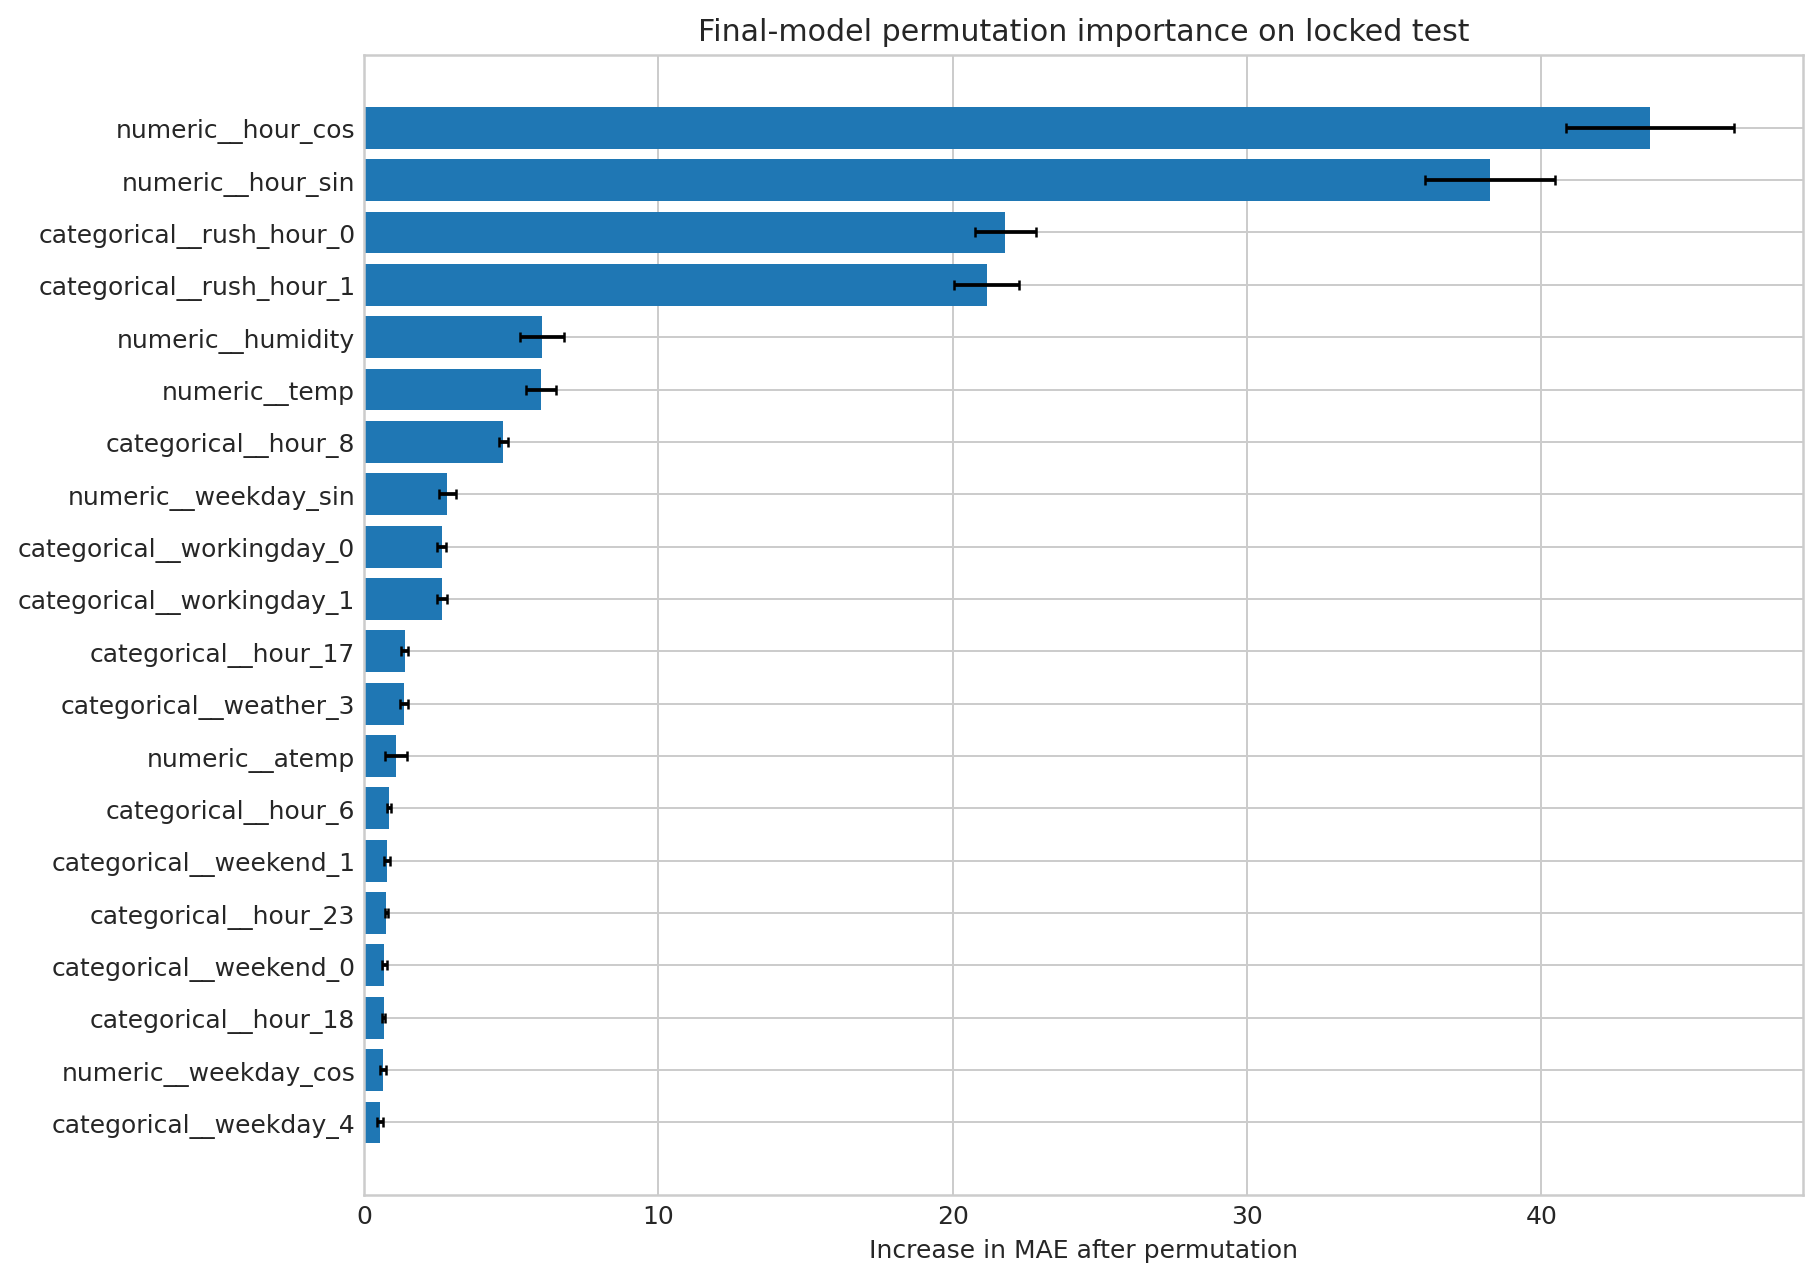

In [7]:
final_metrics = pd.read_csv(TABLES / "final_locked_test_metrics.csv")
audit = pd.read_csv(TABLES / "final_leakage_reproducibility_audit.csv")
display(final_metrics)
display(audit)
display(Image(filename=str(FIGURES / "residuals_vs_predictions.png"), width=850))
display(Image(filename=str(FIGURES / "permutation_importance.png"), width=850))

**Interpretation.** The Random Forest achieved RMSLE 0.3739 versus 0.5255 for seasonal naive, meeting the predeclared improvement criteria. Positive residuals show underprediction in the later quarter. Cyclical hour features dominate permutation importance, but correlated inputs can redistribute importance. SHAP was unavailable and was not claimed.

## 8. Deployment and limitations

The dashboard uses a development-only trained artifact and project-relative paths. The final test contains only season code 4, the data cover 2011–2012, and the tree-spread interval is not calibrated. Deployment therefore requires drift monitoring, newer data, and human oversight.

The raw Kaggle data are intentionally excluded from publication. See `README.md`, `artifacts/reports/MODEL_CARD.md`, `artifacts/reports/DATA_CARD.md`, and `../docs/WINDOWS_SETUP.md`.